# Mühlenanwendungsfall — Datenerhebung

Erste Stufe von Kapitel 4. Wo Kapitel 3 den Datenstrom *erzeugt*, wird er hier
*erhoben*: stationäre Betriebspunkte einer realen Vertikalrollenmühle, rund
vierzehn je Tag über knapp fünf Jahre. Kapitel 3 arbeitet mit Millionen Samples
auf äquidistantem Raster; hier sind es fünfstellige Punktzahlen auf einer
unregelmäßigen Zeitachse. Daraus folgt alles Weitere: Fenster, Toleranzen und
Refraktärzeiten sind ab hier in **Tagen** zu denken, nicht in Samples.

Das Notebook erzeugt die Artefakte, die die vier folgenden lesen:

| Artefakt | Inhalt |
|---|---|
| `data_stream` | Produktionsstrom als Betriebspunkte |
| `data_doe1`, `data_doe2` | die beiden Feldexperimente als Betriebspunkte |
| `data_train1`, `data_train2` | dieselben Kampagnen als Abtastzeilen |
| `data_calibrations` | datierte Wartungskampagnen |

**Aufbereitung.** Die Rohdaten wurden zu Betriebspunkten verdichtet: ein
Mittelwert je Intervall zwischen zwei Sollwertänderungen, fünf Minuten
Einschwingzeit, mindestens zehn Minuten Haltezeit, lange Intervalle in
Zweistundenstücke geteilt. Zwei Erfassungsraten stoßen dabei aneinander — der
ältere Teil liegt gröber abgetastet vor. Die Zielgröße ist die Summe der drei
Antriebsleistungen je Aufgabemenge; der Spanndruck ist das Mittel zweier
Sensoren. Die Qualitätsgröße (Mahlfeinheit) fehlt in der Lieferung
vollständig.

In [1]:
FORCE_RECOMPUTE = True  # True = alle Cache-Stufen neu rechnen
IS_FINAL = False         # True: schreibt zusaetzlich den stabilen Stand

In [2]:
SOURCE = "production"
TARGET_CLIP = (5.0, 120.0)   # kWh/t; ausserhalb: Messfehler, kein Betriebspunkt
SEED = 42

In [3]:
import os
import sys
from pathlib import Path

# Die Wurzel muss stehen, bevor irgendetwas aus src importiert wird.
work_dir = Path.cwd()
base_dir = Path(os.environ.get("BASE_DIR") or next(
    p for p in (work_dir, *work_dir.parents) if (p / "pyproject.toml").exists()))
for _p in (str(base_dir), str(base_dir / "src"), str(work_dir)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

data_dir = base_dir / "data" / "mill"       # Artefakte, wie bei tep und syn
raw_dir = data_dir / "raw"                  # die aufbereiteten Quelldaten
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"
for _d in (data_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

from src.utils import mill_io as mio

print(f"Daten:     {raw_dir}")
print(f"Artefakte: {data_dir}")

Daten:     c:\git\process_optimization_concept_drift\data\mill\raw
Artefakte: c:\git\process_optimization_concept_drift\data\mill


In [4]:
import numpy as np
import pandas as pd
from src.utils import run_registry as rr

rr.assert_current()

data_store = rr.mill_data_store(data_dir)
ledger = rr.run_ledger(work_dir)
plot_store = rr.mill_plot_store(plot_dir, ledger=ledger)
res_store = rr.mill_results_store(results_dir, ledger=ledger)

FEATURES, TARGET, CONTEXT = mio.FEATURES, mio.TARGET, list(mio.CONTEXT)
LIMIT = mio.TAGS.set_index("name")["maximum"]
rng = np.random.default_rng(SEED)
print(f"{len(FEATURES)} Merkmale, Ziel {TARGET}, {len(CONTEXT)} Kontextgroessen")

8 Merkmale, Ziel total_specific_energy, 6 Kontextgroessen


## Produktionsstrom

In [5]:
data_cfg = rr.RunConfig({"source": SOURCE, "features": FEATURES,
                         "target_clip": list(TARGET_CLIP), "seed": SEED})
print(f"data_cfg = {data_cfg.id}")

if data_store.exists("data_stream", data_cfg, rekey=True) and not FORCE_RECOMPUTE:
    stream = data_store.load("data_stream", data_cfg, rename=True, rekey=True)
    print(f"aus Cache: {len(stream)} Betriebspunkte")
else:
    stream = mio.load_operating_points(raw_dir, SOURCE)
    n0 = len(stream)
    stream = stream.dropna(subset=[c for c in FEATURES if c in stream.columns])
    stream = stream[stream[TARGET].between(*TARGET_CLIP)]
    n_clip = n0 - len(stream)

    # Die Stunden der beiden Feldexperimente stehen auch im Produktionsstrom --
    # dieselbe Anlage, dieselbe Zeit, nur anders geschnitten. Blieben sie drin,
    # waere DOE2 keine unabhaengige Generalisierungsreferenz mehr, sondern
    # teilweise Trainingsmaterial (Entscheidung K5).
    _spans = [(d.index[0], d["end"].max())
              for d in (mio.load_doe(raw_dir, w, level="points") for w in ("1", "2"))]
    _in_doe = pd.Series(False, index=stream.index)
    for a, b in _spans:
        _in_doe |= (stream.index >= a) & (stream.index <= b)
    stream = stream[~_in_doe]

    print(f"{n0} Fenster geliefert")
    print(f"  - {n_clip:5d}  Merkmal fehlt oder Zielgroesse ausserhalb {TARGET_CLIP}")
    print(f"  - {int(_in_doe.sum()):5d}  liegen in einem Feldexperiment")
    print(f"  = {len(stream):5d}  Betriebspunkte")
    data_store.save(stream, "data_stream", data_cfg)

data_cfg = 062c6877
23449 Fenster geliefert
  -  3818  Merkmal fehlt oder Zielgroesse ausserhalb (5.0, 120.0)
  -    40  liegen in einem Feldexperiment
  = 19591  Betriebspunkte


In [6]:
info = mio.describe_stream(stream)
print(info.to_string())

n_points                             19591
t_start                2021-11-26 00:36:00
t_end                  2026-09-07 22:15:06
span_days                      1746.902153
points_per_day                   11.214709
gap_median_days                   0.075463
gap_max_days                     12.230903
duration_median_min             104.616667
target_mean                      37.422817
target_std                        4.730889
n_missing                                0


### Nennbereich der Anlage

Die Modelle skalieren **nicht** auf den Datenbereich, sondern auf feste Grenzen
aus der Anlagenkonfiguration (`mill_tags.csv`, `mill_train.FixedRangeScaler`).
Kapitel 2 begründet das: ein Bezugsrahmen, der sich mit dem Datenstrom
mitbewegt, verdeckt genau die Verschiebung, die hier untersucht wird. Der Preis
ist, dass die Grenzen veralten können — deshalb steht die Frage am Anfang.

In [7]:
ranges = mio.range_report(stream)
pd.set_option("display.width", 160)
print(ranges.drop(columns=["n_below"])
      .to_string(index=False, float_format=lambda x: f"{x:.2f}"))

                         name unit  range_min  range_max  observed_min  observed_max  n_above  share_pct  scale_ratio                      kind
                    feed_rate  t/h       0.00      35.00         12.00         42.00     5120      26.13         1.20 Betrieb ueber Nennbereich
             classifier_speed    %       0.00     100.00         69.99        118.27     4888      24.95         1.18 Betrieb ueber Nennbereich
             tension_pressure  bar       0.00     250.00        116.13        215.88        0       0.00         0.86                         -
               mill_fan_speed    %       0.00     100.00         70.00         96.00        0       0.00         0.96                         -
             main_drive_speed    %       0.00     100.00         77.06        100.02       28       0.14         1.00          Anschlagrauschen
recirculation_damper_position    %       0.00     100.00         22.18        100.23       39       0.20         1.00          Anschlagr

In [8]:
# Wann faengt die Ueberschreitung an? SHIFT_DATE ist der frueheste Zeitpunkt,
# ab dem sie dauerhaft wird -- unten in der Abbildung wiederverwendet.
SHIFT_DATE = None
for _c in ranges.loc[ranges["kind"] == "Betrieb ueber Nennbereich", "name"]:
    _q = stream.groupby(pd.Grouper(freq="QS"))[_c].agg(
        n="size", ueber=lambda v: 100.0 * (v > LIMIT[_c]).mean(), max="max")
    _first = _q.index[_q["ueber"] > 20.0]
    print(f"{_c}  (Nenngrenze {LIMIT[_c]:g})")
    print(_q.to_string(float_format=lambda x: f"{x:.1f}"))
    if len(_first):
        print(f"  -> dauerhaft darueber ab {_first[0]:%m/%Y}\n")
        SHIFT_DATE = min(SHIFT_DATE or _first[0], _first[0])
print(f"SHIFT_DATE = {SHIFT_DATE:%d.%m.%Y}")

feed_rate  (Nenngrenze 35)
               n  ueber  max
start                       
2021-10-01   382    0.0 30.0
2022-01-01   804    0.0 25.0
2022-04-01  1100    0.0 26.0
2022-07-01   931    0.0 26.0
2022-10-01   935    0.0 26.0
2023-01-01   895    0.0 27.0
2023-04-01   938    0.0 27.0
2023-07-01   907    0.0 27.0
2023-10-01  1002    0.0 26.0
2024-01-01   998    0.0 29.0
2024-04-01  1140    0.0 30.0
2024-07-01  1147    0.0 30.0
2024-10-01  1243    0.0 33.0
2025-01-01  1081    0.0 33.0
2025-04-01  1128   59.1 40.0
2025-07-01  1169   88.6 40.0
2025-10-01  1266   77.6 41.0
2026-01-01   984   93.5 42.0
2026-04-01   873   97.9 42.0
2026-07-01   668   98.8 42.0
  -> dauerhaft darueber ab 04/2025

classifier_speed  (Nenngrenze 100)
               n  ueber   max
start                        
2021-10-01   382    0.0  94.0
2022-01-01   804    0.0  97.0
2022-04-01  1100    0.0 100.0
2022-07-01   931    0.0  94.0
2022-10-01   935    0.0  89.0
2023-01-01   895    0.0 100.0
2023-04-01   938    0.0 

Beide Überschreitungen sind gefahrener Betrieb, kein Messfehler: nach den
Feldexperimenten wurde der bisherige Arbeitspunkt als nicht optimal erkannt und
die Anlage nach oben optimiert. Der Befund ist datierbar — bis dahin liegt kein
einziges Fenster über der Grenze, danach zwei Drittel bis drei Viertel.

Damit ist er zweierlei: eine **dokumentierte Verschiebung der
Eingangsverteilung** mit bekanntem Zeitpunkt und bekannter Ursache, also neben
den Kalibrierungen die zweite Ereignisart, gegen die eine Detektion geprüft
werden kann — sie wirkt auf $p(\mathbf{x})$, nicht auf $p(y \mid \mathbf{x})$.
Und **kein Anlass, die Skalierung zu ändern**: der Nennbereich ist der der
Anlage, die skalierten Werte laufen über 1,0 hinaus, und genau das sollen sie.

### Naht und Lücken

Zwei Eigenheiten des Stroms, die jede Fensterrechnung betreffen. Die **Naht**
trennt die beiden Erfassungsraten; eine Änderung der Signalstatistik dort kann
ein Artefakt des Quellenwechsels sein statt Drift. Die **Lücken** sind Tage
ohne einen einzigen Betriebspunkt — in keiner Quelle vorhanden, also nicht
nachzutragen.

In [9]:
SEAM = stream.index[stream["nominal_hz"] >= 0.5][0] if "nominal_hz" in stream else None
if SEAM is not None:
    _vor, _nach = stream.index < SEAM, stream.index >= SEAM
    print(f"Naht {SEAM:%d.%m.%Y}: {int(_vor.sum())} Punkte davor "
          f"({mio.points_per_day(stream.index[_vor]):.2f}/Tag), "
          f"{int(_nach.sum())} danach "
          f"({mio.points_per_day(stream.index[_nach]):.2f}/Tag)")

LUECKEN = mio.gaps(stream, min_days=1.0)
print(f"\n{len(LUECKEN)} Luecken ab einem Tag, zusammen "
      f"{LUECKEN['tage'].sum():.0f} von {info['span_days']:.0f} Tagen "
      f"({100 * LUECKEN['tage'].sum() / info['span_days']:.1f} %)")
print(LUECKEN.assign(tage=LUECKEN["tage"].round(1)).head(5).to_string(index=False))

Naht 04.09.2023: 6595 Punkte davor (10.21/Tag), 12996 danach (11.82/Tag)

71 Luecken ab einem Tag, zusammen 215 von 1747 Tagen (12.3 %)
                von                 bis  tage
2022-02-11 20:22:00 2022-02-24 01:54:30  12.2
2023-12-24 01:09:47 2024-01-04 12:33:21  11.5
2022-01-19 06:49:50 2022-01-28 16:03:10   9.4
2022-07-28 03:56:00 2022-08-04 10:04:50   7.3
2022-09-19 04:04:30 2022-09-26 09:05:50   7.2


### Was ein Kapitel-3-Fenster hier bedeutet

Übertragen wird die Methodik, nicht die Zahl.

In [10]:
_ppd = info["points_per_day"]
print(f"{_ppd:.2f} Betriebspunkte je Tag\n")
for k, v in {"KSWIN min_num_instances = 180": 180, "KSWIN Fenster = 32": 32,
             "RMSE Fenster = 44": 44, "syn TOLERANCE = 1000": 1000,
             "syn COOLDOWN = 5000": 5000}.items():
    print(f"  {k:32s} {v:6d} Punkte = {v / _ppd:5.0f} Tage")
print("\nUmgekehrt -- so rechnet Kapitel 4:")
for d in (1, 3, 7, 14, 30, 90):
    print(f"  {d:3d} Tage -> {mio.days_to_points(d, stream.index):5d} Punkte")

11.21 Betriebspunkte je Tag

  KSWIN min_num_instances = 180       180 Punkte =    16 Tage
  KSWIN Fenster = 32                   32 Punkte =     3 Tage
  RMSE Fenster = 44                    44 Punkte =     4 Tage
  syn TOLERANCE = 1000               1000 Punkte =    89 Tage
  syn COOLDOWN = 5000                5000 Punkte =   446 Tage

Umgekehrt -- so rechnet Kapitel 4:
    1 Tage ->    11 Punkte
    3 Tage ->    34 Punkte
    7 Tage ->    79 Punkte
   14 Tage ->   157 Punkte
   30 Tage ->   336 Punkte
   90 Tage ->  1009 Punkte


## Die beiden Feldexperimente

Beide Kampagnen liegen als geschnittene Segmente vor — eine Datei ist ein
gefahrener Betriebspunkt. Die erste steht am Anfang des Produktionszeitraums,
die zweite rund anderthalb Jahre später: das Modell wird auf der ersten
trainiert, die Adaption über den Betrieb dazwischen beobachtet, und die zweite
prüft, was das Modell danach noch kann.

Dieselben Stunden stehen auch im Produktionsstrom, nur anders geschnitten. Sie
sind dort oben entfernt worden — sonst wäre die zweite Kampagne keine
unabhängige Referenz, sondern teilweise Trainingsmaterial.

In [11]:
doe_cfg = rr.RunConfig({"features": FEATURES, "target_clip": list(TARGET_CLIP),
                        "level": "points"})
doe = {}
for _w in ("1", "2"):
    _case = f"data_doe{_w}"
    if data_store.exists(_case, doe_cfg, rekey=True) and not FORCE_RECOMPUTE:
        doe[_w] = data_store.load(_case, doe_cfg, rename=True, rekey=True)
        continue
    _d = mio.load_doe(raw_dir, _w, level="points")
    _d = _d[_d[TARGET].between(*TARGET_CLIP)].dropna(
        subset=[c for c in FEATURES if c in _d.columns])
    doe[_w] = _d
    data_store.save(_d, _case, doe_cfg)

for _w, _d in doe.items():
    _dt = (_d.index[0] - stream.index[0]).days
    print(f"DOE{_w}: {len(_d):3d} Betriebspunkte, {_d.index[0]:%d.%m.%Y} - "
          f"{_d.index[-1]:%d.%m.%Y}, Tag {_dt} des Produktionszeitraums")

print("\nMittelwerte im Vergleich:")
print(pd.DataFrame({"Produktion": stream[FEATURES + [TARGET]].mean(),
                    **{f"DOE{k}": v[FEATURES + [TARGET]].mean()
                       for k, v in doe.items()}})
      .to_string(float_format=lambda x: f"{x:.2f}"))

DOE1:  18 Betriebspunkte, 26.11.2021 - 28.11.2021, Tag 0 des Produktionszeitraums
DOE2:  28 Betriebspunkte, 18.03.2023 - 20.03.2023, Tag 477 des Produktionszeitraums

Mittelwerte im Vergleich:
                               Produktion   DOE1   DOE2
feed_rate                           29.88  21.67  21.86
classifier_speed                    95.55  90.05  90.23
tension_pressure                   176.10 161.93 153.11
mill_fan_speed                      85.23  83.76  85.70
main_drive_speed                    86.76  82.16  85.95
recirculation_damper_position       60.78  61.16  60.95
stack_damper_position               97.72  99.93  99.99
hotgas_generator_load               27.70  19.25   3.84
total_specific_energy               37.42  44.45  43.77


### Trainingszeilen

Das statische MLP aus Abschnitt 2.2.4 lernt auf den **Zeilen** der stationären
Phasen, nicht auf achtzehn Mittelwerten. Die Phasenkennung `bp` trägt in
*mill_model* den Gruppen-Split: gesplittet wird nach Betriebspunkt, sonst
stünden benachbarte Sekunden desselben Punktes in Training und Test.

In [12]:
train = {}
row_cfg = rr.RunConfig({"features": FEATURES, "target_clip": list(TARGET_CLIP),
                        "level": "rows"})
for _w in ("1", "2"):
    _case = f"data_train{_w}"
    if data_store.exists(_case, row_cfg, rekey=True) and not FORCE_RECOMPUTE:
        train[_w] = data_store.load(_case, row_cfg, rename=True, rekey=True)
    else:
        _r = mio.load_doe(raw_dir, _w, level="rows")
        _r = _r[_r[TARGET].between(*TARGET_CLIP)].dropna(
            subset=[c for c in FEATURES if c in _r.columns])
        train[_w] = _r
        data_store.save(_r, _case, row_cfg)
    print(f"data_train{_w}: {len(train[_w])} Zeilen, "
          f"{train[_w]['bp'].nunique()} Phasen")

data_train1: 27402 Zeilen, 18 Phasen
data_train2: 76882 Zeilen, 28 Phasen


## Kalibrierungen der Walzenhöhe

Der Kalibrierkanal trägt einen Offset, den die Wartung auf null setzt, wenn die
Walzen auf dem Teller liegen. Jede Änderung ist ein protokollierter
Schreibvorgang der Steuerung — kein aus dem Signal geschätzter Zeitpunkt,
sondern die Ereignisreferenz des Kapitels.

Was sie **nicht** ist: eine Wartungsdokumentation. Ein Walzenwechsel ohne
Neusetzen des Offsets steht nicht darin, und der Zusammenhang zwischen
Walzenhöhe und Zielgröße ist schwach. Die Kalibrierung markiert einen Eingriff,
sie erklärt ihn nicht.

In [13]:
CALIBRATIONS = mio.calibration_dates(raw_dir)
data_store.save([str(t) for t in CALIBRATIONS], "data_calibrations", data_cfg)

_g = pd.Series(CALIBRATIONS).diff().dt.days.dropna()
print(f"{len(CALIBRATIONS)} Kampagnen, {CALIBRATIONS[0]:%d.%m.%Y} bis "
      f"{CALIBRATIONS[-1]:%d.%m.%Y}")
print(f"Abstand: Median {_g.median():.0f} d, min {_g.min():.0f} d, "
      f"max {_g.max():.0f} d")
print(f"im Zeitraum des Produktionsstroms: "
      f"{sum(stream.index[0] <= t <= stream.index[-1] for t in CALIBRATIONS)}")

58 Kampagnen, 19.03.2022 bis 01.09.2026
Abstand: Median 24 d, min 2 d, max 80 d
im Zeitraum des Produktionsstroms: 58


## Abdeckung des Merkmalsraums

Das Argument für die Feldexperimente: der reguläre Betrieb belegt den
Stellgrößenraum ungleich — er fährt, was sich bewährt hat. Die Experimente
erweitern ihn, aber nicht überall: bei Hauptantriebsdrehzahl, Sichterdrehzahl
und Spanndruck gehen sie über das hinaus, was in den zwei Monaten um die
Kampagne gefahren wurde, bei der **Aufgabemenge nicht**. Die Durchsatzachse
bleibt dem Produktionsbetrieb überlassen — und genau auf ihr verschiebt sich
später der Arbeitspunkt.

Deshalb zwei verschiedene Projektionen: links die Ebene, in der die Experimente
den Raum erweitern, rechts die, in der er sich mit der Zeit verschiebt.

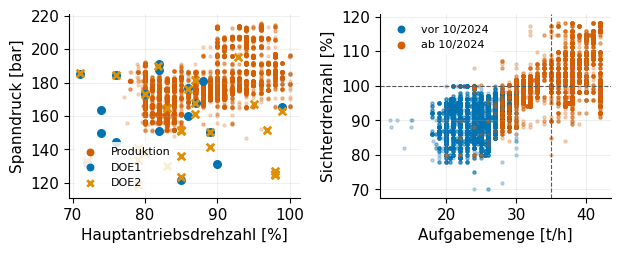

In [14]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

w = ts.fig_width()
DOE_PAIR = ("main_drive_speed", "tension_pressure")   # dort erweitern die Kampagnen
SHIFT_PAIR = ("feed_rate", "classifier_speed")        # dort verschiebt sich der Betrieb
LABEL = {"feed_rate": "Aufgabemenge [t/h]", "classifier_speed": "Sichterdrehzahl [%]",
         "main_drive_speed": "Hauptantriebsdrehzahl [%]",
         "tension_pressure": "Spanndruck [bar]"}


def _legend(ax, **kw):
    leg = ax.legend(fontsize=8, frameon=True, framealpha=0.85, edgecolor="none", **kw)
    for h in leg.legend_handles:          # Marker deckend, sonst unsichtbar
        h.set_alpha(1.0)
        if hasattr(h, "set_sizes"):
            h.set_sizes([22])


fig, axes = plt.subplots(1, 2, figsize=(w, w * 0.42))

_x, _y = DOE_PAIR
axes[0].scatter(stream[_x], stream[_y],
                **ts.scatter("drift_afflicted", s=5, alpha=0.20), label="Produktion")
for _w_, _m, _col in (("1", "o", "drift_free"), ("2", "x", "highlight")):
    if _w_ in doe:
        axes[0].scatter(doe[_w_][_x], doe[_w_][_y], marker=_m, s=30,
                        color=ts.C[_col], label=f"DOE{_w_}", zorder=3)
axes[0].set_xlabel(LABEL[_x])
axes[0].set_ylabel(LABEL[_y])
_legend(axes[0], loc="lower left")

_x, _y = SHIFT_PAIR
_e, _l = stream[stream.index < SHIFT_DATE], stream[stream.index >= SHIFT_DATE]
axes[1].scatter(_e[_x], _e[_y], s=5, alpha=0.25, color=ts.C["drift_free"],
                label=f"vor {SHIFT_DATE:%m/%Y}")
axes[1].scatter(_l[_x], _l[_y], s=5, alpha=0.25, color=ts.C["drift_afflicted"],
                label=f"ab {SHIFT_DATE:%m/%Y}")
axes[1].axvline(LIMIT[_x], color="0.35", lw=0.8, ls="--")
axes[1].axhline(LIMIT[_y], color="0.35", lw=0.8, ls="--")
axes[1].set_xlabel(LABEL[_x])
axes[1].set_ylabel(LABEL[_y])
_legend(axes[1], loc="upper left")

for ax in axes:
    ax.grid(True, alpha=0.2)
fig.tight_layout()
plot_store.save_figure(fig, "data_coverage", data_cfg, final=IS_FINAL,
                       savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
plt.show()

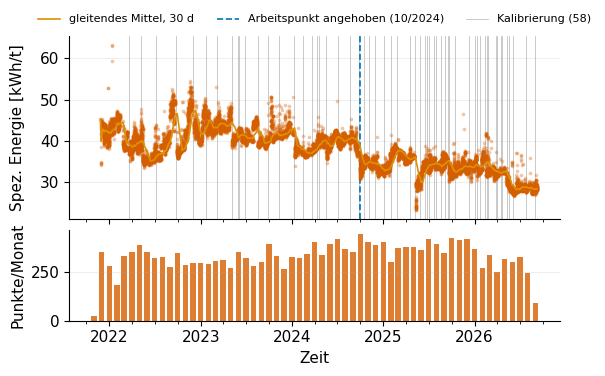

In [15]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(w, w * 0.66), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})

for _t in CALIBRATIONS:
    axes[0].axvline(_t, color="0.7", lw=0.5, zorder=0)
axes[0].scatter(stream.index, stream[TARGET],
                **ts.scatter("drift_afflicted", s=3, alpha=0.25), zorder=2)
_roll = stream[TARGET].rolling("30D").mean()
axes[0].plot(_roll.index, _roll, color=ts.C["highlight"], lw=1.2, zorder=3,
             label="gleitendes Mittel, 30 d")
axes[0].axvline(SHIFT_DATE, color=ts.C["drift_free"], lw=1.2, ls="--", zorder=1,
                label=f"Arbeitspunkt angehoben ({SHIFT_DATE:%m/%Y})")
axes[0].plot([], [], color="0.7", lw=0.5, label=f"Kalibrierung ({len(CALIBRATIONS)})")
axes[0].set_ylabel("Spez. Energie [kWh/t]")
axes[0].legend(frameon=False, fontsize=8, ncol=3, loc="lower center",
               bbox_to_anchor=(0.5, 1.01))
axes[0].grid(True, axis="y", alpha=0.2)

_month = stream.groupby(pd.Grouper(freq="MS")).size()
axes[1].bar(_month.index, _month.values, width=22,
            color=ts.C["drift_afflicted"], alpha=0.8)
axes[1].set_ylabel("Punkte/Monat")
axes[1].set_xlabel("Zeit")
axes[1].grid(True, axis="y", alpha=0.2)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))

fig.align_ylabels(axes)
fig.autofmt_xdate(rotation=0, ha="center")
plot_store.save_figure(fig, "data_timeline", data_cfg, final=IS_FINAL,
                       savefig_kwargs={"dpi": 300, "bbox_inches": "tight"},
                       archive_kwargs={"dpi": 300, "bbox_inches": "tight"})
plt.show()

## Ergebnisse speichern

In [16]:
from src.utils import results_export as rx

ledger.bind("data", parents={})

doc = (rx.ResultDoc()
       .set("source", SOURCE)
       .set("features", FEATURES)
       .set("target", TARGET)
       .integer("n_points", len(stream))
       .num("span_days", float(info["span_days"]), 0)
       .num("points_per_day", float(info["points_per_day"]), 2)
       .num("gap_median_days", float(info["gap_median_days"]), 2)
       .num("gap_max_days", float(info["gap_max_days"]), 1)
       .num("duration_median_min", float(info["duration_median_min"]), 0)
       .num("target_mean", float(info["target_mean"]), 2)
       .num("target_std", float(info["target_std"]), 2)
       .set("t_start", str(info["t_start"]))
       .set("t_end", str(info["t_end"]))
       .set("operating_point_shift", str(SHIFT_DATE))
       .set("seam", str(SEAM))
       .integer("n_gaps", len(LUECKEN))
       .num("gap_days_total", float(LUECKEN["tage"].sum()), 0)
       .set("out_of_range", {r["name"]: {"kind": r["kind"],
                                         "n_above": int(r["n_above"]),
                                         "scale_ratio": round(r["scale_ratio"], 3)}
                             for _, r in ranges.iterrows() if r["kind"] != "-"})
       .integer("n_calibrations", len(CALIBRATIONS))
       .set("doe", {k: {"n": int(len(v)), "start": str(v.index[0]),
                        "end": str(v.index[-1]),
                        "n_rows": int(len(train[k])) if k in train else None,
                        "target_mean": float(v[TARGET].mean())}
                    for k, v in doe.items()}))
doc.save(res_store, "data", data_cfg, final=IS_FINAL)

Umfassende Ergebnisse -> None


In [17]:
from src.utils import latex_export as lx

mx = lx.MacroExport("automatisch erzeugt aus mill_data.ipynb - nicht manuell editieren")
mx.comment("Datenlage")
mx.integer("millNPoints", len(stream))
mx.integer("millSpanDays", int(round(info["span_days"])))
mx.num("millPointsPerDay", float(info["points_per_day"]), 1)
mx.num("millDurationMedianMin", float(info["duration_median_min"]), 0)
mx.num("millTargetMean", float(info["target_mean"]), 1)
mx.num("millTargetStd", float(info["target_std"]), 2)
mx.integer("millNFeatures", len(FEATURES))
mx.integer("millNGaps", len(LUECKEN))
mx.num("millGapDays", float(LUECKEN["tage"].sum()), 0)

mx.comment("Feldexperimente")
for _w, _d in doe.items():
    mx.integer(f"millDoe{_w}N", len(_d))
    if _w in train:
        mx.integer(f"millDoe{_w}Rows", len(train[_w]))

mx.comment("Kalibrierungen")
mx.integer("millNCalibrations", len(CALIBRATIONS))
mx.num("millCalibIntervalDays",
       float(pd.Series(CALIBRATIONS).diff().dt.days.median()), 0)

mx.comment("Anhebung des Arbeitspunkts")
mx.raw("millShiftDate", f"{SHIFT_DATE:%m/%Y}")
for _, _r in ranges[ranges["kind"] == "Betrieb ueber Nennbereich"].iterrows():
    _n = "".join(p.capitalize() for p in _r["name"].split("_"))
    mx.num(f"millScaleRatio{_n}", float(_r["scale_ratio"]), 2)
    mx.num(f"millOverRangeShare{_n}", float(_r["share_pct"]), 0)

mx.comment("Kapitel-3-Fenster in Tagen")
mx.num("millKswinMinInstDays", 180 / info["points_per_day"], 0)
mx.num("millKswinWindowDays", 32 / info["points_per_day"], 0)
mx.save(res_store, "data", data_cfg, final=IS_FINAL)

LaTeX-Makros -> None

% automatisch erzeugt aus mill_data.ipynb - nicht manuell editieren

% Datenlage
\newcommand{\millNPoints}{19591}
\newcommand{\millSpanDays}{1747}
\newcommand{\millPointsPerDay}{11{,}2}
\newcommand{\millDurationMedianMin}{105}
\newcommand{\millTargetMean}{37{,}4}
\newcommand{\millTargetStd}{4{,}73}
\newcommand{\millNFeatures}{8}
\newcommand{\millNGaps}{71}
\newcommand{\millGapDays}{215}

% Feldexperimente
\newcommand{\millDoe1N}{18}
\newcommand{\millDoe1Rows}{27402}
\newcommand{\millDoe2N}{28}
\newcommand{\millDoe2Rows}{76882}

% Kalibrierungen
\newcommand{\millNCalibrations}{58}
\newcommand{\millCalibIntervalDays}{24}

% Anhebung des Arbeitspunkts
\newcommand{\millShiftDate}{10/2024}
\newcommand{\millScaleRatioFeedRate}{1{,}20}
\newcommand{\millOverRangeShareFeedRate}{26}
\newcommand{\millScaleRatioClassifierSpeed}{1{,}18}
\newcommand{\millOverRangeShareClassifierSpeed}{25}

% Kapitel-3-Fenster in Tagen
\newcommand{\millKswinMinInstDays}{16}
\newcommand{\millKswi

In [18]:
print(f"data_cfg.id = {data_cfg.id}   -> RUN_ID in mill_model")
print(f"doe_cfg.id  = {doe_cfg.id}   -> DOE_ID in mill_model")
print(f"row_cfg.id  = {row_cfg.id}   -> TRAIN_ID in mill_model")

data_cfg.id = 062c6877   -> RUN_ID in mill_model
doe_cfg.id  = f0686c11   -> DOE_ID in mill_model
row_cfg.id  = 2890af02   -> TRAIN_ID in mill_model
